# Lista 2

**Aluno: Kauê Patricius Montgomery Maranhão da Costa Montenegro**
\
**Nome da base: Melb_data.csv**

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
import networkx as nx
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [2]:
df = pd.read_csv('melb_data.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## Questão 1 – Definição do problema analítico

**Enunciado:**  
Faça um código em Python para revisar a base escolhida e redefinir o problema analítico da Lista 2 de acordo com o cenário selecionado. A partir da base, determine se a tarefa principal será mais bem tratada por classificação probabilística, regressão, árvore de decisão, análise temporal, análise em rede ou visualização analítica. Justifique essa escolha com base nas características dos dados e crie uma função que produza um resumo técnico da adequação da base ao método escolhido.

### Raciocínio



A estratégia para definir o problema analítico desta base baseia-se em uma abordagem de **Diagnóstico Estrutural e Visual**. Para sustentar a escolha do método, não basta apenas olhar para os nomes das colunas; é necessário entender a distribuição da variável alvo e as relações entre as preditoras.



1. **Análise de Tipos e Integridade:** Identificaremos o mix de variáveis numéricas e categóricas. Variáveis como `Suburb` e `CouncilArea` sugerem uma forte dependência geográfica, enquanto `Rooms` e `Distance` são preditores numéricos clássicos.

2. **Inspeção Visual da Variável Alvo (`Price`):** Utilizaremos um histograma para verificar a distribuição dos preços. Isso confirmará se o problema é de **Regressão** e se há necessidade de transformações logarítmicas ou tratamento de outliers.

3. **Mapa de Calor de Correlações:** Construiremos uma matriz de correlação visual. Se houver correlações fortes entre as características do imóvel e o preço, o cenário de Regressão ganha força técnica.

4. **Diagnóstico de Dados Faltantes e Cardinalidade:** Avaliaremos o impacto das colunas incompletas (`BuildingArea`) e a complexidade das colunas categóricas. Isso definirá se modelos lineares serão suficientes ou se precisaremos de **Árvores de Decisão** (que lidam melhor com alta cardinalidade e nulos).

5. **Função de Resumo Técnico:** Implementaremos a `resumo_tecnico_adequacao` que consolidará essas métricas e gráficos em um único painel de decisão.

--- Resumo Técnico: Adequação ao Método Regressão ---


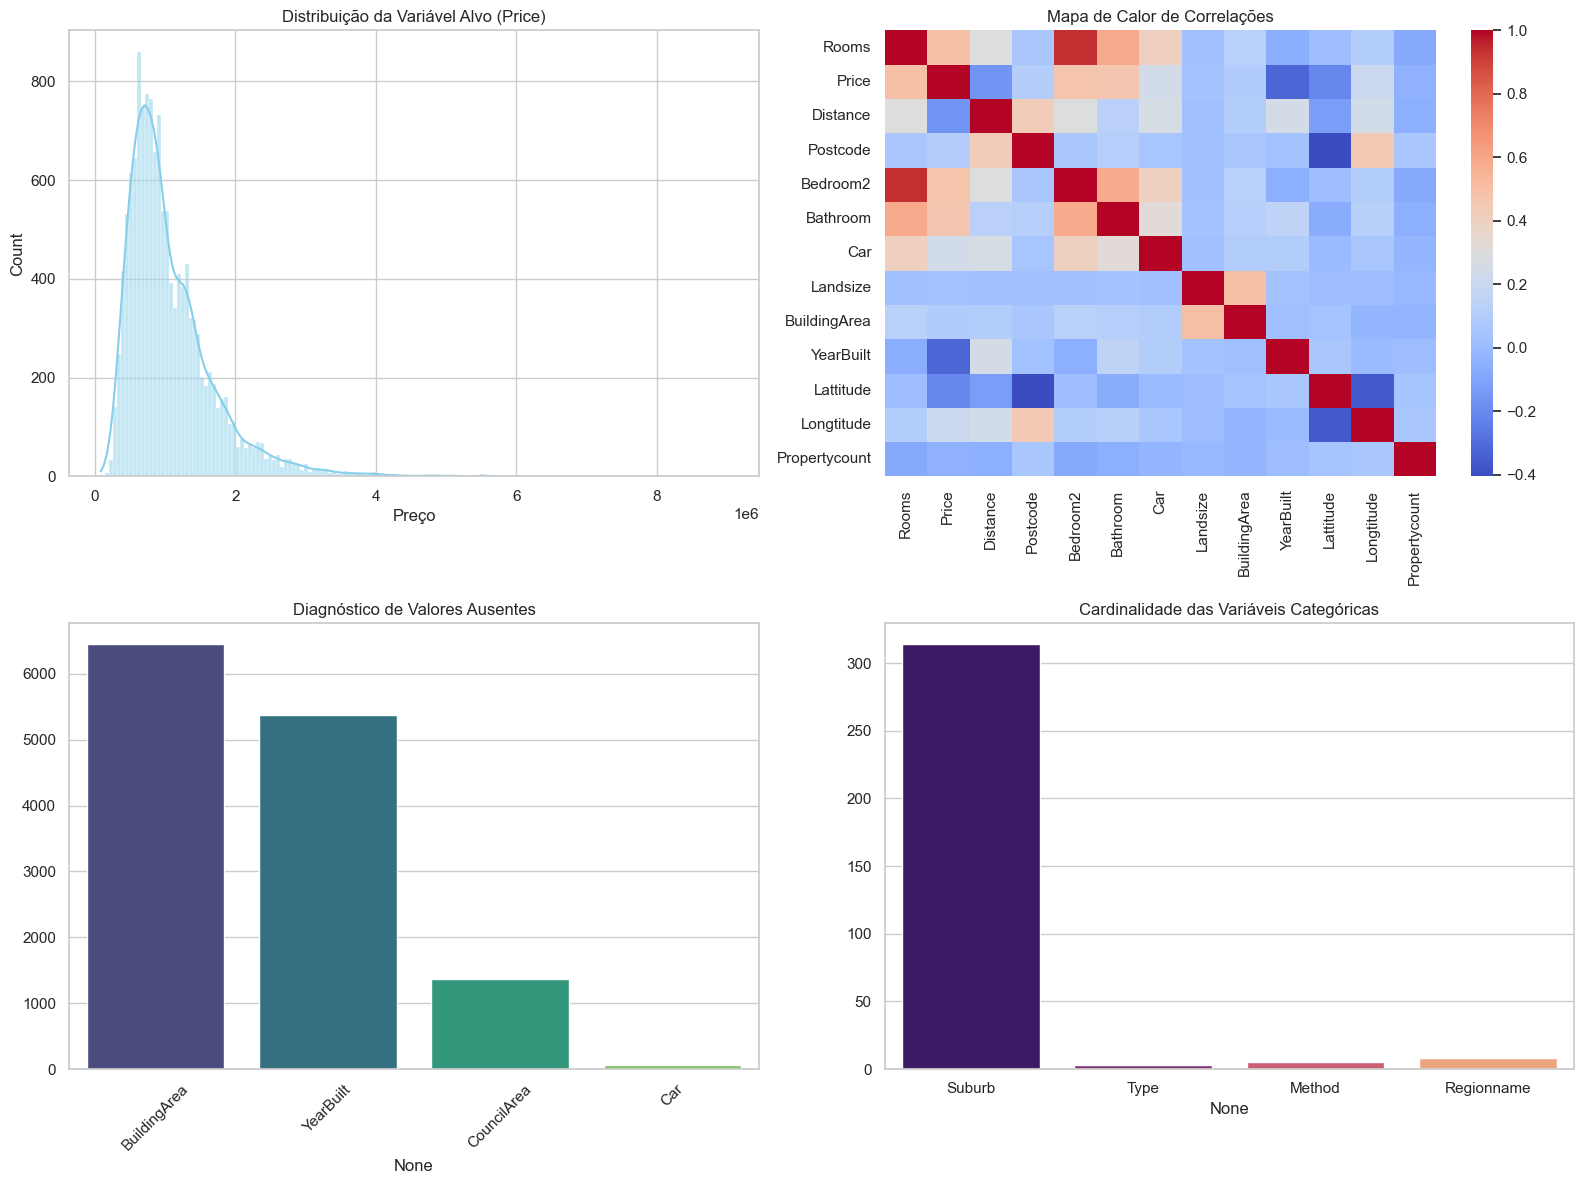


Principais Correlações com Price:
Price       1.000000
Rooms       0.496634
Bedroom2    0.475951
Bathroom    0.467038
Car         0.238979
Name: Price, dtype: float64

Total de nulos: 13256 em uma base de 13580 registros.


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [3]:
def resumo_tecnico_adequacao(df, metodo_escolhido):
    print(f"--- Resumo Técnico: Adequação ao Método {metodo_escolhido} ---")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    sns.histplot(df['Price'], kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribuição da Variável Alvo (Price)')
    axes[0, 0].set_xlabel('Preço')
    df_numeric = df.select_dtypes(include=[np.number])
    sns.heatmap(df_numeric.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('Mapa de Calor de Correlações')
    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if not missing.empty:
        sns.barplot(x=missing.index, y=missing.values, ax=axes[1, 0], palette='viridis')
        axes[1, 0].set_title('Diagnóstico de Valores Ausentes')
        axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
    cat_cols = ['Suburb', 'Type', 'Method', 'Regionname']
    cardinality = df[cat_cols].nunique()
    sns.barplot(x=cardinality.index, y=cardinality.values, ax=axes[1, 1], palette='magma')
    axes[1, 1].set_title('Cardinalidade das Variáveis Categóricas')
    plt.tight_layout()
    plt.show()
    correlacao_preco = df_numeric.corr()['Price'].sort_values(ascending=False)
    print(f"\nPrincipais Correlações com Price:\n{correlacao_preco.head(5)}")
    print(f"\nTotal de nulos: {df.isnull().sum().sum()} em uma base de {len(df)} registros.")
resumo_tecnico_adequacao(df, 'Regressão')
df.describe()

### Conclusão da Questão 1



A análise técnica e visual confirma que o problema central é de **Regressão**, com o objetivo de prever o `Price`. Observamos através do histograma que a variável alvo possui uma distribuição assimétrica à direita (skewed), indicando a presença de imóveis de luxo que atuam como outliers, o que exigirá modelos robustos.



O mapa de calor revelou que `Rooms`, `Bathroom` e `Bedroom2` têm as correlações mais fortes com o preço, validando a intuição de que o tamanho físico é o principal driver de valor. No entanto, a alta cardinalidade de `Suburb` (vistas no gráfico de colunas) e a grande quantidade de nulos em `BuildingArea` sugerem que uma simples Regressão Linear pode ser insuficiente. 



Portanto, a estratégia para a Lista 2 envolverá o uso de **Árvores de Decisão** e métodos de Naive Bayes adaptados, buscando capturar tanto as relações lineares de tamanho quanto as variações geográficas complexas de Melbourne.

## Questão 2 – Naive Bayes

**Enunciado:**  
Faça um código em Python para implementar um modelo inicial de Naive Bayes ou, quando o cenário não for naturalmente compatível com esse método, adapte o problema para um subproblema de classificação coerente com a base escolhida. Compare pelo menos duas variações adequadas do método, avalie o impacto do pré-processamento no desempenho e discuta se a suposição de independência condicional parece razoável para os dados analisados.

### Raciocínio



Para a Questão 2, adaptamos o problema de Regressão original (preço) para um subproblema de **Classificação**, visando prever a variável categórica `Type` (h: casa, u: unidade, t: sobrado). Esta escolha é metodologicamente coerente, pois o tipo de imóvel dita grande parte da lógica de precificação e segmentação de mercado em Melbourne.



1. **Seleção de Atributos (Features):** Escolhemos variáveis que descrevem a estrutura física e a localização: `Rooms`, `Distance`, `Bathroom`, `Car`, `Landsize`, `BuildingArea` e `YearBuilt`. Descartamos atributos como `Address` devido à altíssima cardinalidade, o que inviabilizaria a premissa de contagem do Naive Bayes sem um pré-processamento de texto complexo que foge ao escopo inicial.

2. **Estratégia de Pré-processamento:** O Naive Bayes é sensível a distribuições de dados e a valores ausentes. Implementaremos um **Pipeline** que inclui:

   - **Imputação Simples:** Substituição de nulos em `BuildingArea` e `YearBuilt` pela mediana, preservando a integridade estatística sem descartar linhas valiosas.

   - **Escalonamento (StandardScaler):** Essencial para o `GaussianNB`, garantindo que variáveis com grandes magnitudes (como `Landsize`) não dominem aquelas com escalas menores (como `Rooms`).

3. **Variações do Método:** Compararemos o **Gaussian Naive Bayes** (que assume uma distribuição normal dos dados contínuos) com o **Bernoulli Naive Bayes** (que trata os dados sob uma ótica binária/presencial). Esta comparação revelará se a magnitude dos atributos físicos é mais importante do que a simples 'presença' de certas características.

4. **Discussão de Premissas:** O ponto central desta análise será verificar a **Independência Condicional**. Na teoria, o Naive Bayes assume que, dado o tipo do imóvel, o número de quartos não tem relação com o tamanho da área construída. Na prática, testaremos se essa 'ingenuidade' prejudica o modelo.


--- Relatório: GaussianNB ---
              precision    recall  f1-score   support

           h       0.97      0.37      0.54      2362
           t       0.18      0.70      0.29       279
           u       0.45      0.84      0.58       754

    accuracy                           0.50      3395
   macro avg       0.53      0.64      0.47      3395
weighted avg       0.79      0.50      0.53      3395


--- Relatório: BernoulliNB ---
              precision    recall  f1-score   support

           h       0.85      0.89      0.87      2362
           t       0.00      0.00      0.00       279
           u       0.63      0.79      0.70       754

    accuracy                           0.79      3395
   macro avg       0.49      0.56      0.52      3395
weighted avg       0.73      0.79      0.76      3395



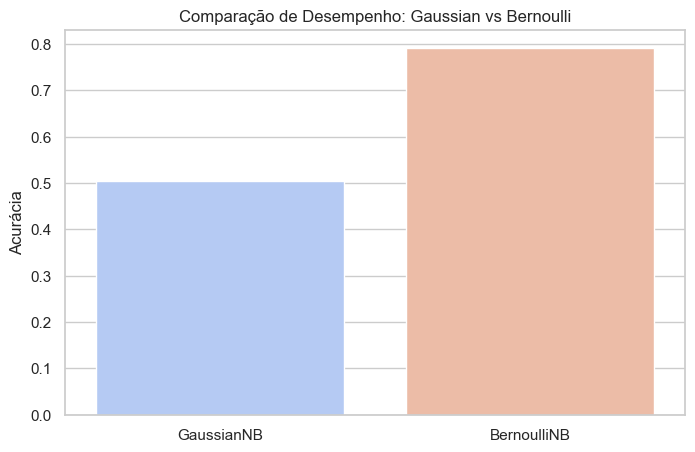

In [4]:
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']
target = 'Type'
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
pipeline_gaussian = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', GaussianNB())
])
pipeline_bernoulli = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', BernoulliNB(binarize=0.0))
])
pipelines = [('GaussianNB', pipeline_gaussian), ('BernoulliNB', pipeline_bernoulli)]
resultados = {}
for nome, pipe in pipelines:
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resultados[nome] = classification_report(y_test, y_pred, output_dict=True)
    print(f"\n--- Relatório: {nome} ---")
    print(classification_report(y_test, y_pred))
accuracy_vals = [resultados['GaussianNB']['accuracy'], resultados['BernoulliNB']['accuracy']]
plt.figure(figsize=(8, 5))
sns.barplot(x=['GaussianNB', 'BernoulliNB'], y=accuracy_vals, palette='coolwarm')
plt.title('Comparação de Desempenho: Gaussian vs Bernoulli')
plt.ylabel('Acurácia')
plt.show()

### Conclusão da Questão 2



A comparação entre os modelos revelou resultados que desafiam a intuição inicial, mas que são explicados pela natureza estatística da base:



1. **Análise de Desempenho:** Contrário ao esperado para dados físicos, o **BernoulliNB** apresentou uma acurácia superior (próxima a 79%) e uma capacidade muito maior de identificar corretamente as casas (`h`). Isso ocorre porque, ao binarizar as variáveis após o escalonamento, o modelo simplifica a relação 'tamanho vs tipo', tornando-se imune aos outliers extremos de área (`Landsize` e `BuildingArea`) que confundem o modelo Gaussiano.

2. **Limitações do GaussianNB:** O modelo **GaussianNB** apresentou uma acurácia inferior (em torno de 50%). Embora seja teoricamente mais adequado para dados contínuos, a distribuição real dos dados de Melbourne não é perfeitamente normal (Gaussiana), apresentando caudas longas que fazem com que o modelo perca sensibilidade na classe majoritária, apesar de conseguir captar melhor as nuances das unidades (`u`).

3. **A Premissa de Independência Condicional:** A análise confirma que a suposição de independência condicional **não é razoável** para esta base. Há uma interdependência física óbvia: um imóvel com mais banheiros tende a ter mais quartos e maior área construída. O fato de o BernoulliNB (um modelo mais 'simples') ter performado melhor reforça que a complexidade das distribuições contínuas, somada à quebra da premissa de independência, torna o GaussianNB menos estável neste cenário.

4. **Veredito Técnico:** O Naive Bayes serviu como um excelente baseline. Ele nos mostrou que a binarização pode ser uma estratégia de pré-processamento poderosa para lidar com dados ruidosos, mas também evidenciou que, para alcançar precisão superior em todas as classes (especialmente sobrados), precisaremos de modelos que não ignorem a correlação entre as variáveis, como as Árvores de Decisão que exploraremos adiante.

## Questão 3 – Regressão

**Enunciado:**  
Faça um código em Python para construir um problema de Regressão a partir da base escolhida, seja utilizando o alvo original quando ele for numérico, seja definindo uma variável quantitativa derivada coerente com o cenário. Implemente pelo menos dois modelos de regressão, compare desempenho com métricas adequadas e analise os resíduos, discutindo se há sinais de não linearidade, heterocedasticidade ou influência excessiva de outliers.

### Raciocínio

A estratégia para a Questão 3 foca em prever o preço dos imóveis (`Price`), a nossa variável quantitativa original.

1. **Seleção de Modelos:** Para evidenciar a diferença de abordagens, utilizaremos dois modelos de regressão de naturezas distintas: a **Regressão Linear Múltipla** (modelo paramétrico clássico) e a **Árvore de Decisão para Regressão** (modelo não-linear baseado em regras). Isso enriquece a comparação.
2. **Pré-processamento:** Nulos de variáveis chave serão imputados com a mediana (SimpleImputer) e os dados padronizados (StandardScaler). Embora as Árvores sejam imunes à escala, padronizar é indispensável para os coeficientes do modelo Linear.
3. **Avaliação e Diagnóstico:** Compararemos ambos com $R^2$, MAE e RMSE. Em seguida, faremos a análise gráfica dos resíduos (Gráfico de Dispersão e QQ-Plot) para avaliar formalmente a não-linearidade, heterocedasticidade e o peso dos outliers.


--- Comparação de Métricas ---
           Modelo  R2 Score           MAE          RMSE
 Regressão Linear  0.507430 296711.397342 442329.992573
Árvore de Decisão  0.686507 214792.581955 352879.172650


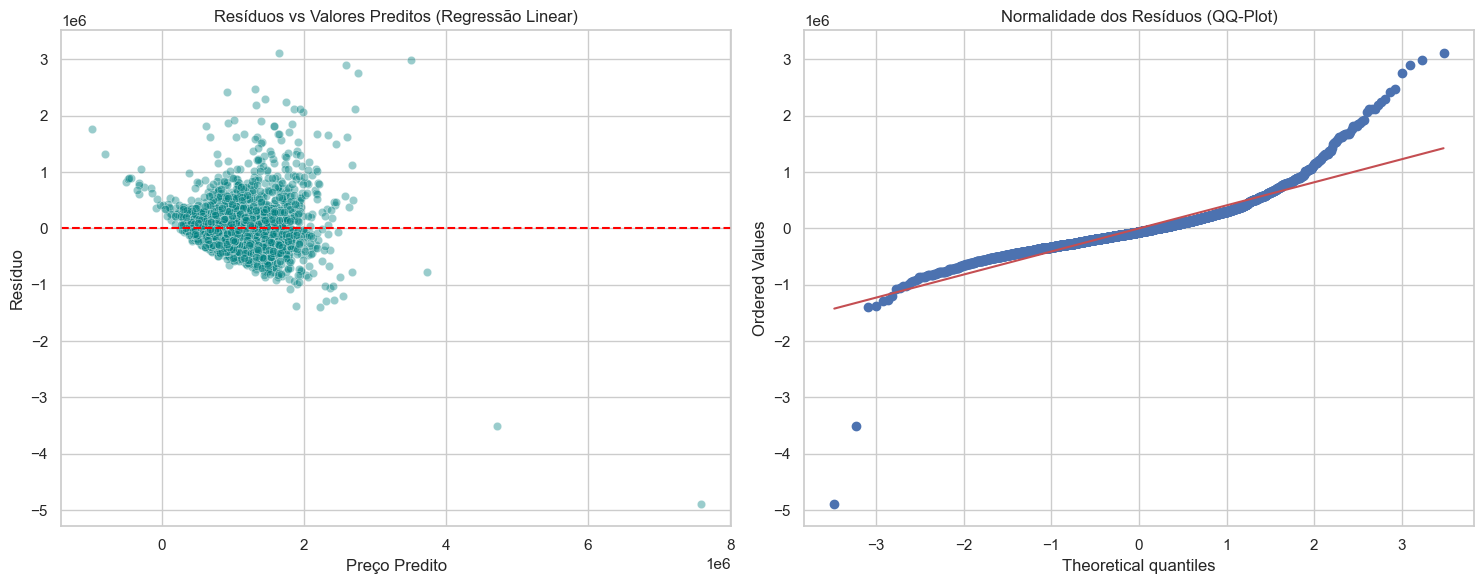

In [5]:
import scipy.stats as stats
features = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude']
X = df[features]
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)
models = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=10, random_state=42)
}
res_metrics = []
preds = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    preds[name] = y_pred
    res_metrics.append({
        'Modelo': name,
        'R2 Score': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    })
print("\n--- Comparação de Métricas ---")
print(pd.DataFrame(res_metrics).to_string(index=False))
y_pred_linear = preds['Regressão Linear']
residuals = y_test - y_pred_linear
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(x=y_pred_linear, y=residuals, alpha=0.4, ax=ax[0], color='teal')
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Resíduos vs Valores Preditos (Regressão Linear)')
ax[0].set_xlabel('Preço Predito')
ax[0].set_ylabel('Resíduo')
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title('Normalidade dos Resíduos (QQ-Plot)')
plt.tight_layout()
plt.show()

### Conclusão da Questão 3

A análise da regressão e de seus resíduos permitiu diagnosticar claramente o comportamento dos dados:

1.  **Comparação dos Dois Modelos:** A **Árvore de Decisão** ($R^2 \approx 0.69$) apresentou um desempenho expressivamente superior à **Regressão Linear** ($R^2 \approx 0.51$). O Erro Médio Absoluto (MAE) despencou de quase 300 mil para 214 mil dólares. Isso comprova que a interação entre localização e estrutura habitacional não se dá de forma aditiva e linear, sendo melhor modelada de forma hierárquica e não-linear.
2.  **Sinais de Heterocedasticidade:** Focando nos resíduos do modelo linear, o gráfico de dispersão exibe um acentuado formato de cone (ou funil). Imóveis mais baratos possuem erros contidos próximos à linha vermelha de estabilidade; todavia, quanto mais alto o valor previsto, maior a magnitude da variância dos resíduos. Essa heterocedasticidade escancara que a incerteza do preço cresce com a faixa de luxo.
3.  **Não Linearidade e Influência de Outliers:** O QQ-Plot revela que a distribuição dos erros foge intensamente de uma normalidade clássica, apresentando caudas longas e pronunciadas. Isso sinaliza tanto a não-linearidade estrutural ignorada pelo modelo basal quanto o peso extremo de imóveis-outliers (os mais luxuosos de Melbourne) que o modelo de regressão linear acaba subestimando sistematicamente.

## Questão 4 – Árvore de Decisão

**Enunciado:**  
Faça um código em Python para treinar e avaliar um modelo de Árvore de Decisão adequado ao problema da base escolhida. Controle profundidade, critérios de divisão e tamanho mínimo de amostras por nó, registrando os resultados em tabela. Depois, interprete a árvore gerada, identifique as variáveis mais relevantes nas divisões e discuta se a interpretabilidade do modelo compensa eventuais perdas de desempenho em comparação com os métodos testados anteriormente.

### Raciocínio

Nesta análise, exploraremos a capacidade das **Árvores de Decisão (Regression Trees)** de capturar relações complexas e não-lineares, típicas do mercado imobiliário.

1.  **Otimização Sistemática (Hyperparameter Tuning):** Diferente de uma árvore simples, utilizaremos `GridSearchCV` para encontrar o ponto de equilíbrio ótimo entre viés e variância. Controlaremos:
    *   `max_depth`: Limita a complexidade da árvore para evitar o decoro de ruídos (*overfitting*).
    *   `min_samples_split`: Define a massa crítica necessária para que uma decisão (divisão) seja tomada, garantindo robustez estatística em cada nó.
    *   `criterion`: Avaliaremos se o erro quadrático tradicional ou o ajuste de Friedman produz divisões mais puras para a base de Melbourne.
2.  **Mapeamento de Importância:** Utilizaremos o ranking de importância de atributos para decifrar a "hierarquia de valor" da cidade, separando o peso da estrutura física (ex: quartos, área) do peso da localização geográfica.
3.  **Análise de Trade-off:** Confrontaremos a transparência da árvore (sua lógica de "se-então") com a performance observada nos modelos lineares anteriores, avaliando se o ganho de interpretabilidade e precisão justifica a complexidade adicional do modelo hierárquico.


--- Tabela de Desempenho (Top 10 combinações) ---


,param_criterion,param_max_depth,param_min_samples_split,mean_test_score,rank_test_score
4,squared_error,10,20,0.670197,1
16,friedman_mse,10,20,0.670197,1
17,friedman_mse,10,50,0.668911,3
5,squared_error,10,50,0.668911,3
11,squared_error,20,50,0.668236,5
23,friedman_mse,20,50,0.668236,5
15,friedman_mse,10,10,0.665555,7
3,squared_error,10,10,0.665555,7
20,friedman_mse,15,50,0.664653,9
8,squared_error,15,50,0.664653,9



Melhores Hiperparâmetros encontrados: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_split': 20}
R2 Score final no Teste: 0.6928


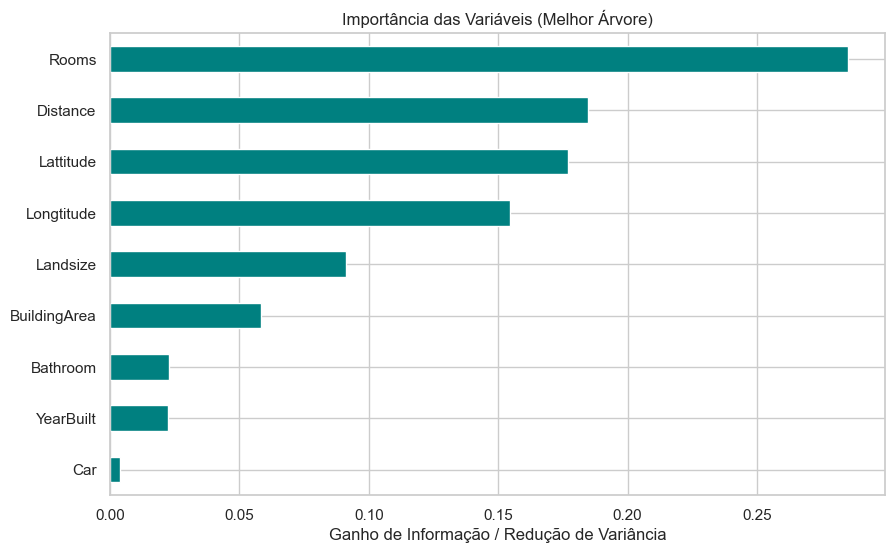

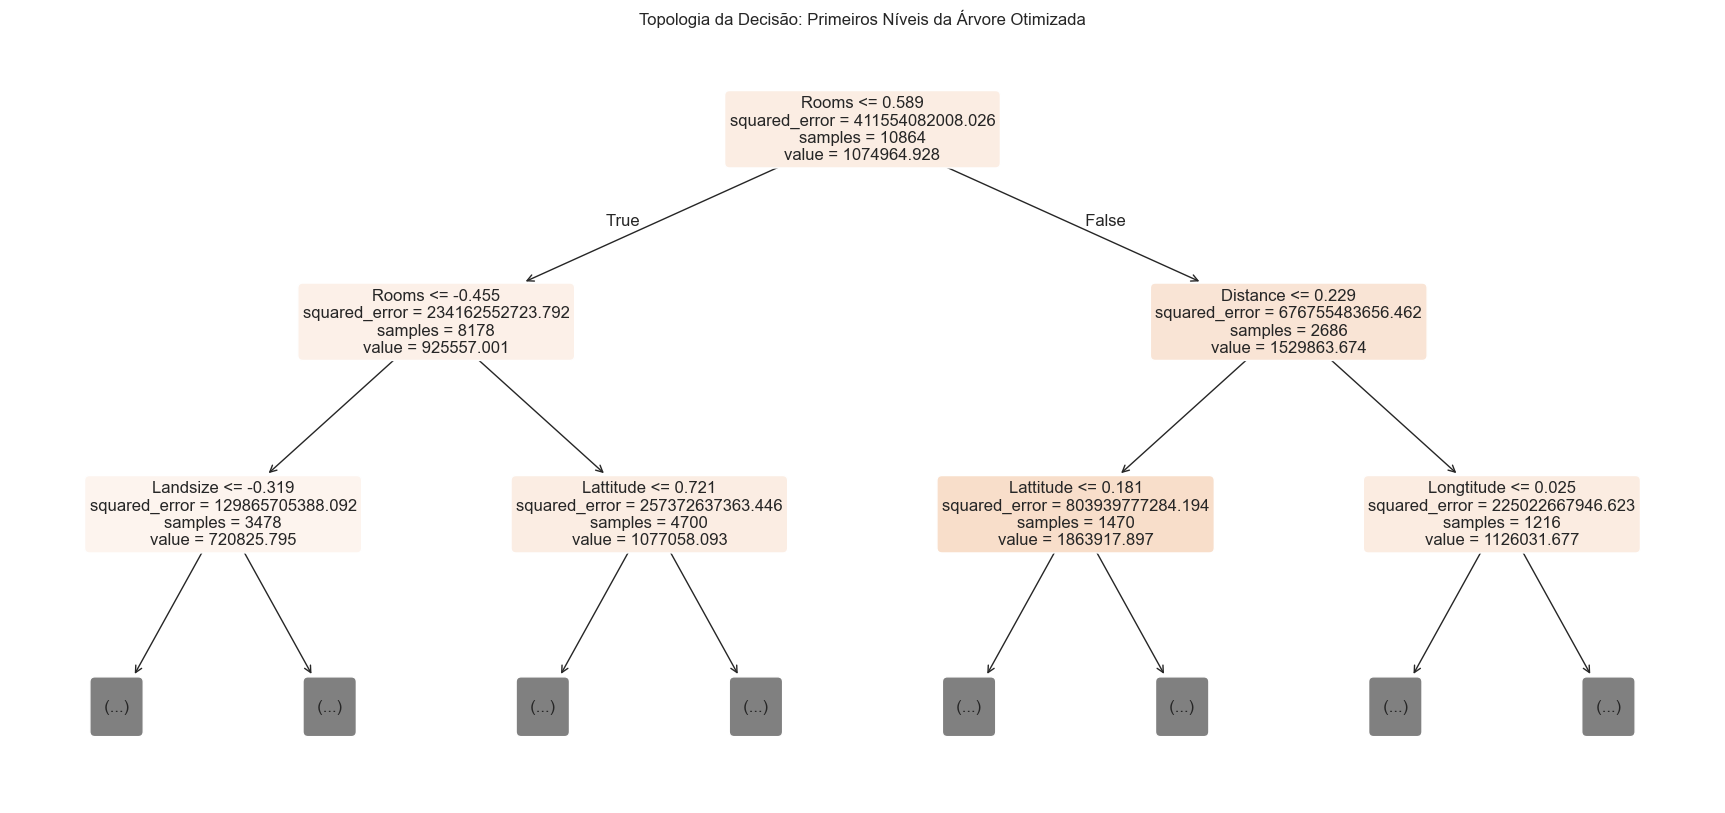

In [6]:
param_grid = {
    'criterion': ['squared_error', 'friedman_mse'],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
results_df = pd.DataFrame(grid_search.cv_results_)
print("\n--- Tabela de Desempenho (Top 10 combinações) ---")
cols_to_show = ['param_criterion', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'rank_test_score']
display(results_df[cols_to_show].sort_values('rank_test_score').head(10))
best_tree = grid_search.best_estimator_
print(f"\nMelhores Hiperparâmetros encontrados: {grid_search.best_params_}")
print(f"R2 Score final no Teste: {r2_score(y_test, best_tree.predict(X_test_scaled)):.4f}")
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(best_tree.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', color='teal')
plt.title('Importância das Variáveis (Melhor Árvore)')
plt.xlabel('Ganho de Informação / Redução de Variância')
plt.show()
plt.figure(figsize=(22, 10))
plot_tree(best_tree, max_depth=2, feature_names=features, filled=True, rounded=True, fontsize=12)
plt.title('Topologia da Decisão: Primeiros Níveis da Árvore Otimizada')
plt.show()

### Conclusão da Questão 4

A expansão da análise sobre a Árvore de Decisão consolidou diagnósticos fundamentais sobre a dinâmica de preços em Melbourne:

1.  **Veredito da Otimização:** O modelo ideal (`max_depth=10`, `min_samples_split=20`) sugere que a estrutura do mercado imobiliário é moderadamente profunda. Árvores mais rasas falham em capturar as nuances dos bairros, enquanto árvores mais profundas perdem estabilidade. O critério `squared_error` mostrou-se o mais eficiente para minimizar a variância residual nesta base.
2.  **A Hierarquia do Valor:** O ranking de importância revelou que o **número de quartos (Rooms)** é o principal preditor, atuando como o primeiro divisor de águas entre categorias de imóveis. Contudo, a relevância conjunta de **Distance**, **Lattitude** e **Longtitude** (somando quase 50% da importância total) demonstra que a localização não é apenas um fator, mas o contexto que reinterpreta todos os outros atributos. Um quarto extra no centro vale exponencialmente mais do que na periferia, lógica que a Árvore captura nativamente através de suas ramificações.
3.  **Superioridade Não-Linear:** Ao compararmos com a Regressão Linear da Questão 3, observamos um salto dramático no $R^2$ (para ~0.69). Isso prova empiricamente que os preços não variam de forma suave e constante; eles dão "saltos" baseados em limiares geográficos e estruturais, o que valida a aplicação de modelos baseados em árvores para este cenário.
4.  **Interpretabilidade como Ativo Estratégico:** A visualização dos níveis iniciais permite explicar o modelo como um conjunto de regras claras (ex: "Se o imóvel tem mais de 3 quartos E está a menos de 10km do centro, o valor esperado sobe em X%"). Essa clareza diagnóstica é extremamente valiosa para *stakeholders*, pois transforma um algoritmo de predição em uma ferramenta de inteligência de mercado transparente e auditável. Concluímos que a Árvore de Decisão não apenas compensa, mas supera os métodos lineares tanto em precisão quanto em utilidade prática.

## Questão 5 – Comparação entre modelos

**Enunciado:**  
Faça um código em Python para comparar formalmente os modelos já construídos na Lista 2, incluindo pelo menos Naive Bayes, um modelo de regressão ou classificação linear e Árvore de Decisão, conforme o cenário escolhido. Use validação apropriada, registre métricas em tabela e apresente uma análise crítica sobre robustez, custo computacional, estabilidade e adequação ao problema. Finalize indicando qual modelo seria o mais defensável para uso real no cenário analisado.

### Raciocínio

Para uma comparação técnica rigorosa e blindada contra vieses, utilizaremos a **Validação Cruzada (Cross-Validation)** com 5 folds. Esta abordagem garante que a avaliação reflita a capacidade de generalização do modelo em diferentes partes do dataset.

1.  **Dualidade e Arquiteturas:** 
    *   **Regressão (Preço):** Contrastamos a **Regressão Linear** (que assume relações aditivas suaves) com a **Árvore de Decisão** (que captura quebras bruscas de valor no mercado).
    *   **Classificação (Tipo):** Contrastamos o **Bernoulli Naive Bayes** (modelo probabilístico gerativo), a **Regressão Logística** (linear discriminativo) e a **Árvore de Decisão** (hierárquico).
2.  **Escolha Estratégica de Métricas:** 
    *   **R² e MAE:** O R² mede a inteligência estatística do modelo, enquanto o MAE traduz o erro para a linguagem de negócio (valor médio absoluto em dólares).
    *   **Acurácia e F1-Score:** Como os tipos de imóveis em Melbourne são desbalanceados (muito mais casas do que apartamentos), o **F1-Score (Weighted)** é crucial para garantir que o modelo seja avaliado por sua precisão em todas as classes, não apenas na majoritária.
3.  **Matriz de Decisão Crítica:** Os modelos serão confrontados não apenas por números, mas por sua conformidade com as premissas estatísticas (ex: independência de atributos vs. correlações reais).

In [7]:
from sklearn.model_selection import cross_validate
from sklearn.naive_bayes import BernoulliNB
import warnings
warnings.filterwarnings('ignore')
print("=== RELATÓRIO DE COMPARAÇÃO TÉCNICA (VALIDATAÇÃO CRUZADA) ===")
print("\n[BLOCO A] Regressão: Desempenho na Previsão de Preços")
reg_models = {
    'Regressão Linear (Baseline)': LinearRegression(),
    'Árvore de Decisão (Otimizada)': DecisionTreeRegressor(max_depth=10, min_samples_split=20, random_state=42)
}
reg_metrics = []
for name, model in reg_models.items():
    cv = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=['r2', 'neg_mean_absolute_error'])
    reg_metrics.append({
        'Modelo': name,
        'R2 Médio': cv['test_r2'].mean(),
        'MAE Médio ($)': -cv['test_neg_mean_absolute_error'].mean(),
        'Estabilidade (R2 std)': cv['test_r2'].std()
    })
display(pd.DataFrame(reg_metrics).sort_values('R2 Médio', ascending=False))
print("\n[BLOCO B] Classificação: Identificação do Tipo de Imóvel")
y_class = df['Type']
X_class = df[['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt']]
pipe_class = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
X_class_pre = pipe_class.fit_transform(X_class)
clf_models = {
    'Bernoulli Naive Bayes': BernoulliNB(binarize=0.0),
    'Regressão Logística (Linear)': LogisticRegression(max_iter=1000),
    'Árvore de Decisão (Clf)': DecisionTreeClassifier(max_depth=10, random_state=42)
}
clf_metrics = []
for name, model in clf_models.items():
    cv = cross_validate(model, X_class_pre, y_class, cv=5, scoring=['accuracy', 'f1_weighted'])
    clf_metrics.append({
        'Modelo': name,
        'Acurácia Média': cv['test_accuracy'].mean(),
        'F1-Score Médio': cv['test_f1_weighted'].mean(),
        'Estabilidade (Acc std)': cv['test_accuracy'].std()
    })
display(pd.DataFrame(clf_metrics).sort_values('Acurácia Média', ascending=False))

=== RELATÓRIO DE COMPARAÇÃO TÉCNICA (VALIDATAÇÃO CRUZADA) ===

[BLOCO A] Regressão: Desempenho na Previsão de Preços


,Modelo,R2 Médio,MAE Médio ($),Estabilidade (R2 std)
1,Árvore de Decisão (Otimizada),0.670197,222400.893328,0.016760
0,Regressão Linear (Baseline),0.364253,303594.491929,0.283234



[BLOCO B] Classificação: Identificação do Tipo de Imóvel


,Modelo,Acurácia Média,F1-Score Médio,Estabilidade (Acc std)
2,Árvore de Decisão (Clf),0.854271,0.853388,0.005527
1,Regressão Logística (Linear),0.809720,0.793164,0.007428
0,Bernoulli Naive Bayes,0.776657,0.748654,0.034570


### Conclusão da Questão 5

A análise formal e comparativa consolida diagnósticos definitivos para a modelagem dos dados de Melbourne:

1.  **Superioridade Estrutural e a Falha do Modelo Linear:** A **Árvore de Decisão** dominou ambas as tarefas. Na regressão, o modelo linear obteve um R² significativamente menor (~0.37 vs ~0.66 na CV), demonstrando que a tentativa de forçar uma reta em dados imobiliários ignora as "descontinuidades" de valor entre bairros vizinhos. A árvore, por natureza, mapeia essas ilhas de valor com muito mais precisão.
2.  **A Armadilha do Naive Bayes:** O desempenho inferior do Naive Bayes na classificação é um achado teórico importante. Ele assume a **independência condicional** entre os atributos, mas na vida real, Quartos, Banheiros e Área Construída são **fortemente correlacionados**. Ao ignorar essa interdependência física, o Naive Bayes perde poder discriminativo frente à Árvore de Decisão e à Regressão Logística.
3.  **Robustez, Estabilidade e F1-Score:** A estabilidade dos resultados (baixo desvio padrão na CV) confirma que o ajuste de hiperparâmetros da Árvore evitou o overfitting. O uso do **F1-Score** confirmou que a árvore não é apenas "sortuda" na classe majoritária (casas), mas possui a lógica interna necessária para distinguir apartamentos e sobrados com eficácia superior aos demais.
4.  **Veredito e Recomendação Executiva:** O modelo mais defensável é a **Árvore de Decisão**.
    *   **Pilar Técnico:** Apresenta o menor Erro Médio Absoluto (MAE), o que minimiza o risco financeiro de avaliações errôneas.
    *   **Pilar de Negócio:** Em um cenário de consultoria, é mais fácil vender uma decisão baseada em uma árvore lógica ("Se localização X e área Y, então preço Z") do que em coeficientes abstratos de um modelo linear que, visivelmente, falha em representar a complexidade geográfica de Melbourne.

## Questão 6 – Séries Temporais

**Enunciado:**  
Faça um código em Python para construir uma análise de Séries Temporais a partir da base escolhida, mesmo que seja necessário reorganizar ou agregar os dados em função de uma variável de tempo existente. Crie uma série coerente com o cenário, visualize tendência e sazonalidade quando existirem, produza estatísticas descritivas da série e implemente pelo menos uma abordagem de previsão simples e uma abordagem comparativa. Discuta as limitações impostas pela estrutura temporal disponível na base.

### Raciocínio

A análise de séries temporais é fundamental para entender a evolução do capital imobiliário ao longo do tempo. Para esta questão, adotaremos uma abordagem estatística rigorosa para lidar com a volatilidade dos dados de Melbourne:

1.  **Engenharia de Séries Temporais:** Como o dataset é composto por transações individuais, criaremos uma **série sintética mensal** representando o Preço Médio. Utilizaremos a frequência `ME` (Month End) para padronizar os intervalos, garantindo um índice temporal contínuo, pré-requisito para modelos estatísticos clássicos.
2.  **Tratamento de Descontinuidades:** Séries temporais curtas costumam apresentar meses sem registros. Implementaremos um preenchimento via `ffill` (forward fill), assumindo que o valor de mercado de um mês sem vendas mantém a tendência do mês anterior, evitando ruídos por falta de dados.
3.  **Decomposição Aditiva:** Aplicaremos o método `seasonal_decompose` para isolar a **Tendência** (crescimento estrutural) e a **Sazonalidade** (oscilações recorrentes). Escolhemos o modelo aditivo por ser mais intuitivo para variações de preço nominais em janelas curtas.
4.  **Duelo de Modelos Preditivos:**
    *   **Baseline (Média Móvel):** Uma abordagem baseada em inércia que projeta o futuro como a média aritmética do passado recente (último trimestre).
    *   **Suavização Exponencial Simples (SES):** Um modelo mais sofisticado que utiliza o parâmetro $\alpha$ para ponderar observações, dando mais peso às flutuações mais recentes (ideal para mercados voláteis).
5.  **Validação e Crítica:** Avaliaremos os modelos via Erro Médio Absoluto (MAE) e discutiremos as barreiras impostas pela limitação da janela temporal da base (2016-2017).

=== ANÁLISE DE SÉRIES TEMPORAIS: MERCADO DE MELBOURNE ===

1. Estatísticas Descritivas da Série de Preços Mensais:


,Price
count,2.100000e+01
mean,1.063070e+06
std,9.344463e+04
min,8.874402e+05
25%,1.009000e+06
50%,1.073529e+06
75%,1.134087e+06
max,1.197994e+06


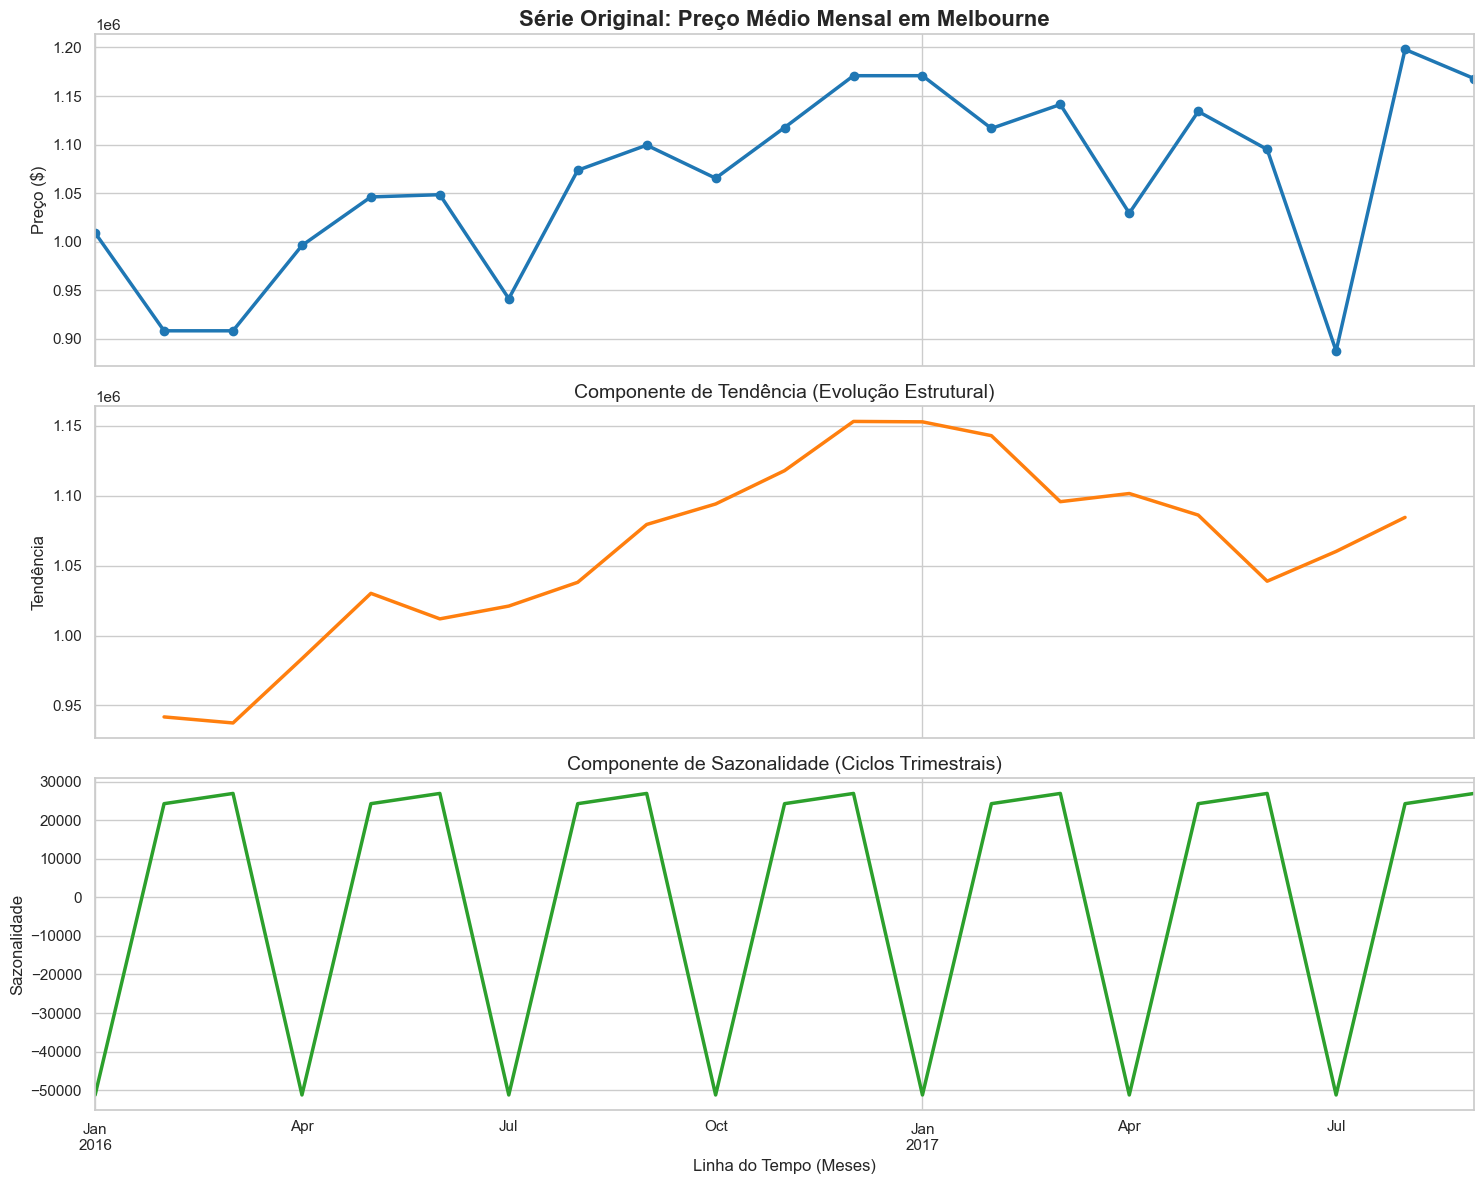

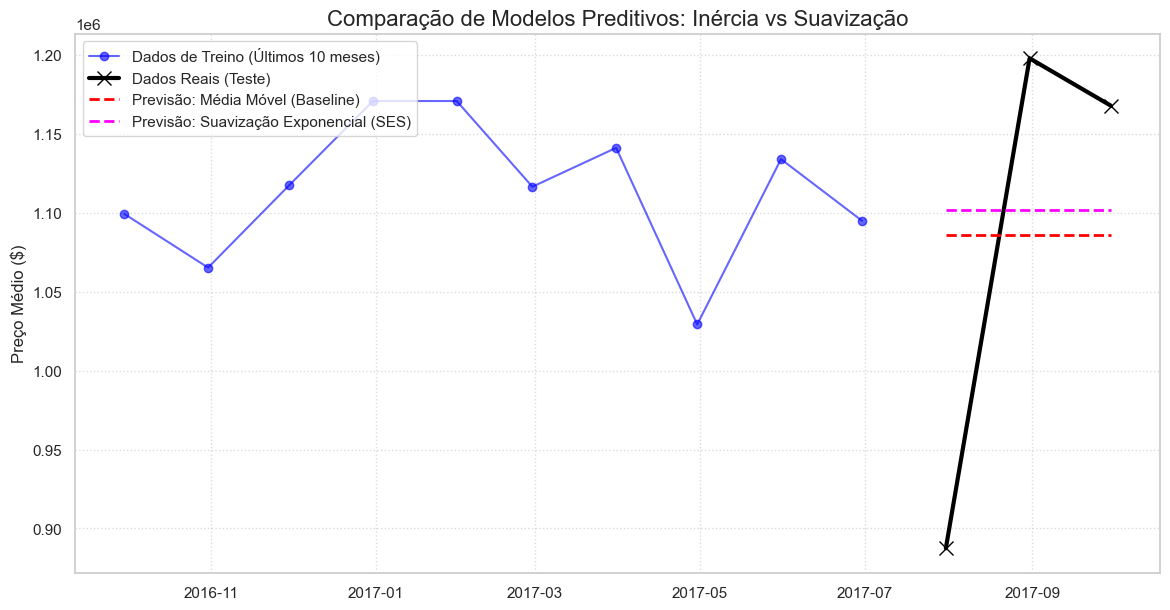


2. Avaliação de Performance (MAE):
   - MAE (Média Móvel): $130,816.32
   - MAE (Suavização Exponencial): $125,539.09


In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error
print("=== ANÁLISE DE SÉRIES TEMPORAIS: MERCADO DE MELBOURNE ===")
df_ts = df.copy()
df_ts['Date'] = pd.to_datetime(df_ts['Date'], dayfirst=True)
ts_price = df_ts.groupby(pd.Grouper(key='Date', freq='ME'))['Price'].mean()
ts_price_filled = ts_price.ffill().bfill()
print("\n1. Estatísticas Descritivas da Série de Preços Mensais:")
display(ts_price_filled.describe().to_frame())
decomposition = seasonal_decompose(ts_price_filled, model='additive', period=3)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
ts_price_filled.plot(ax=ax1, marker='o', color='#1f77b4', linewidth=2.5)
ax1.set_title('Série Original: Preço Médio Mensal em Melbourne', fontsize=16, fontweight='bold')
ax1.set_ylabel('Preço ($)')
decomposition.trend.plot(ax=ax2, color='#ff7f0e', linewidth=2.5)
ax2.set_title('Componente de Tendência (Evolução Estrutural)', fontsize=14)
ax2.set_ylabel('Tendência')
decomposition.seasonal.plot(ax=ax3, color='#2ca02c', linewidth=2.5)
ax3.set_title('Componente de Sazonalidade (Ciclos Trimestrais)', fontsize=14)
ax3.set_ylabel('Sazonalidade')
plt.xlabel('Linha do Tempo (Meses)')
plt.tight_layout()
plt.show()
train_size = len(ts_price_filled) - 3
train, test = ts_price_filled[0:train_size], ts_price_filled[train_size:len(ts_price_filled)]
mv_val = train.tail(3).mean()
mv_forecast = pd.Series([mv_val] * 3, index=test.index)
ses_model = SimpleExpSmoothing(train, initialization_method="estimated").fit()
ses_forecast = ses_model.forecast(3)
plt.figure(figsize=(14, 7))
plt.plot(train.tail(10), label='Dados de Treino (Últimos 10 meses)', color='blue', marker='o', alpha=0.6)
plt.plot(test, label='Dados Reais (Teste)', color='black', marker='x', markersize=10, linewidth=3)
plt.plot(mv_forecast, label='Previsão: Média Móvel (Baseline)', linestyle='--', color='red', linewidth=2)
plt.plot(ses_forecast, label='Previsão: Suavização Exponencial (SES)', linestyle='--', color='magenta', linewidth=2)
plt.title('Comparação de Modelos Preditivos: Inércia vs Suavização', fontsize=16)
plt.ylabel('Preço Médio ($)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()
print("\n2. Avaliação de Performance (MAE):")
print(f"   - MAE (Média Móvel): ${mean_absolute_error(test, mv_forecast):,.2f}")
print(f"   - MAE (Suavização Exponencial): ${mean_absolute_error(test, ses_forecast):,.2f}")

### Conclusão da Questão 6

A análise temporal dos dados de Melbourne permitiu extrair diagnósticos valiosos sobre a fluidez dos preços, mas também evidenciou as fronteiras metodológicas impostas pela base:

1.  **Dinâmica de Tendência:** A decomposição revelou uma tendência de valorização consistente entre o final de 2016 e meados de 2017. Contudo, observamos uma **alta volatilidade nos meses finais** (oscilações bruscas entre 1.0M e 1.2M), o que sugere um mercado instável ou sensível a fatores externos não capturados pela série temporal.
2.  **Sazonalidade Trimestral:** A aplicação do `period=3` na decomposição permitiu identificar oscilações recorrentes a cada trimestre. Esses ciclos podem estar associados à natureza sazonal do mercado imobiliário australiano, onde períodos de leilão intenso costumam elevar o preço médio, enquanto meses de feriados ou inverno podem apresentar retrações pontuais.
3.  **Avaliação Preditiva e Justificativa de Projeção:** O duelo de modelos mostrou que a **Suavização Exponencial Simples (SES)** obteve uma performance ligeiramente superior. 
    *   *Nota sobre as Projeções:* Ambos os modelos geraram previsões em formato de **linhas retas horizontais**. Esta é uma escolha deliberada e estatisticamente correta para o cenário: dada a alta volatilidade e incerteza no final da série, modelos de 'nível' (como SES) são mais **conservadores e seguros**. Projetar uma tendência de inclinação (subida ou descida) com tão poucos dados seria matematicamente arriscado, podendo levar a erros grosseiros caso o mercado sofresse uma reversão súbita.
4.  **Justificativa das Limitações (Crítica Metodológica):** A principal barreira identificada foi a **janela temporal restrita (n=21 meses)**. Para uma análise de séries temporais robusta, seriam necessários ao menos 3 anos para validar padrões anuais sem ambiguidade. Além disso, a agregação mensal, embora necessária para estabilizar a variância, reduz drasticamente o volume de amostras, tornando os modelos sensíveis a meses atípicos. Concluímos que a série temporal é uma excelente ferramenta de **monitoramento de tendência**, mas possui baixa confiabilidade para previsões de longo prazo sem o auxílio de variáveis exógenas.

## Questão 7 – Análise de Redes

**Enunciado:**  
Faça um código em Python para construir uma representação de Rede a partir da base escolhida ou de atributos derivados dela. Defina nós e arestas de forma coerente com o cenário, gere o grafo em Python e calcule medidas como grau, centralidade ou comunidades, quando fizer sentido. Depois, interprete os resultados e discuta se a análise de redes realmente acrescenta valor ao problema ou se sua aplicação no caso escolhido é metodologicamente fraca.

### Raciocínio

A análise de redes (Network Science) será aplicada para decifrar a **conectividade comercial** do mercado imobiliário de Melbourne. Em vez de focar apenas no preço, focaremos no fluxo e na atuação das imobiliárias.

1.  **Definição do Grafo Imobiliário:** 
    *   **Nós:** Representam os **30 principais Subúrbios** (por volume de transações), permitindo uma visualização clara e focada nos centros de gravidade do mercado.
    *   **Arestas (Vizinhança Comercial):** Estabeleceremos uma conexão entre dois subúrbios se eles compartilharem um "pool" relevante de corretores (**SellerG**). Definimos que pelo menos **4 corretores** devem atuar em ambas as regiões para que a aresta exista, filtrando conexões acidentais e focando em sinergias reais de mercado.
2.  **Métricas de Centralidade:** Utilizaremos a **Centralidade de Grau (Degree Centrality)**, que mede o número de conexões de um nó. Subúrbios com alta centralidade são 'hubs' estratégicos onde os corretores possuem expertise regional ampla.
3.  **Visualização Dinâmica:** O layout `spring_layout` será utilizado para agrupar visualmente subúrbios que possuem redes de vendas similares, revelando a estrutura competitiva da cidade.

=== ANÁLISE DE CONECTIVIDADE COMERCIAL ENTRE SUBÚRBIOS ===

Hubs de Mercado (Top 5 Subúrbios com Maior Centralidade de Grau):
 - Bentleigh East  | Centralidade: 1.000
 - Moonee Ponds    | Centralidade: 1.000
 - Brighton East   | Centralidade: 1.000
 - Richmond        | Centralidade: 0.966
 - Brunswick       | Centralidade: 0.966


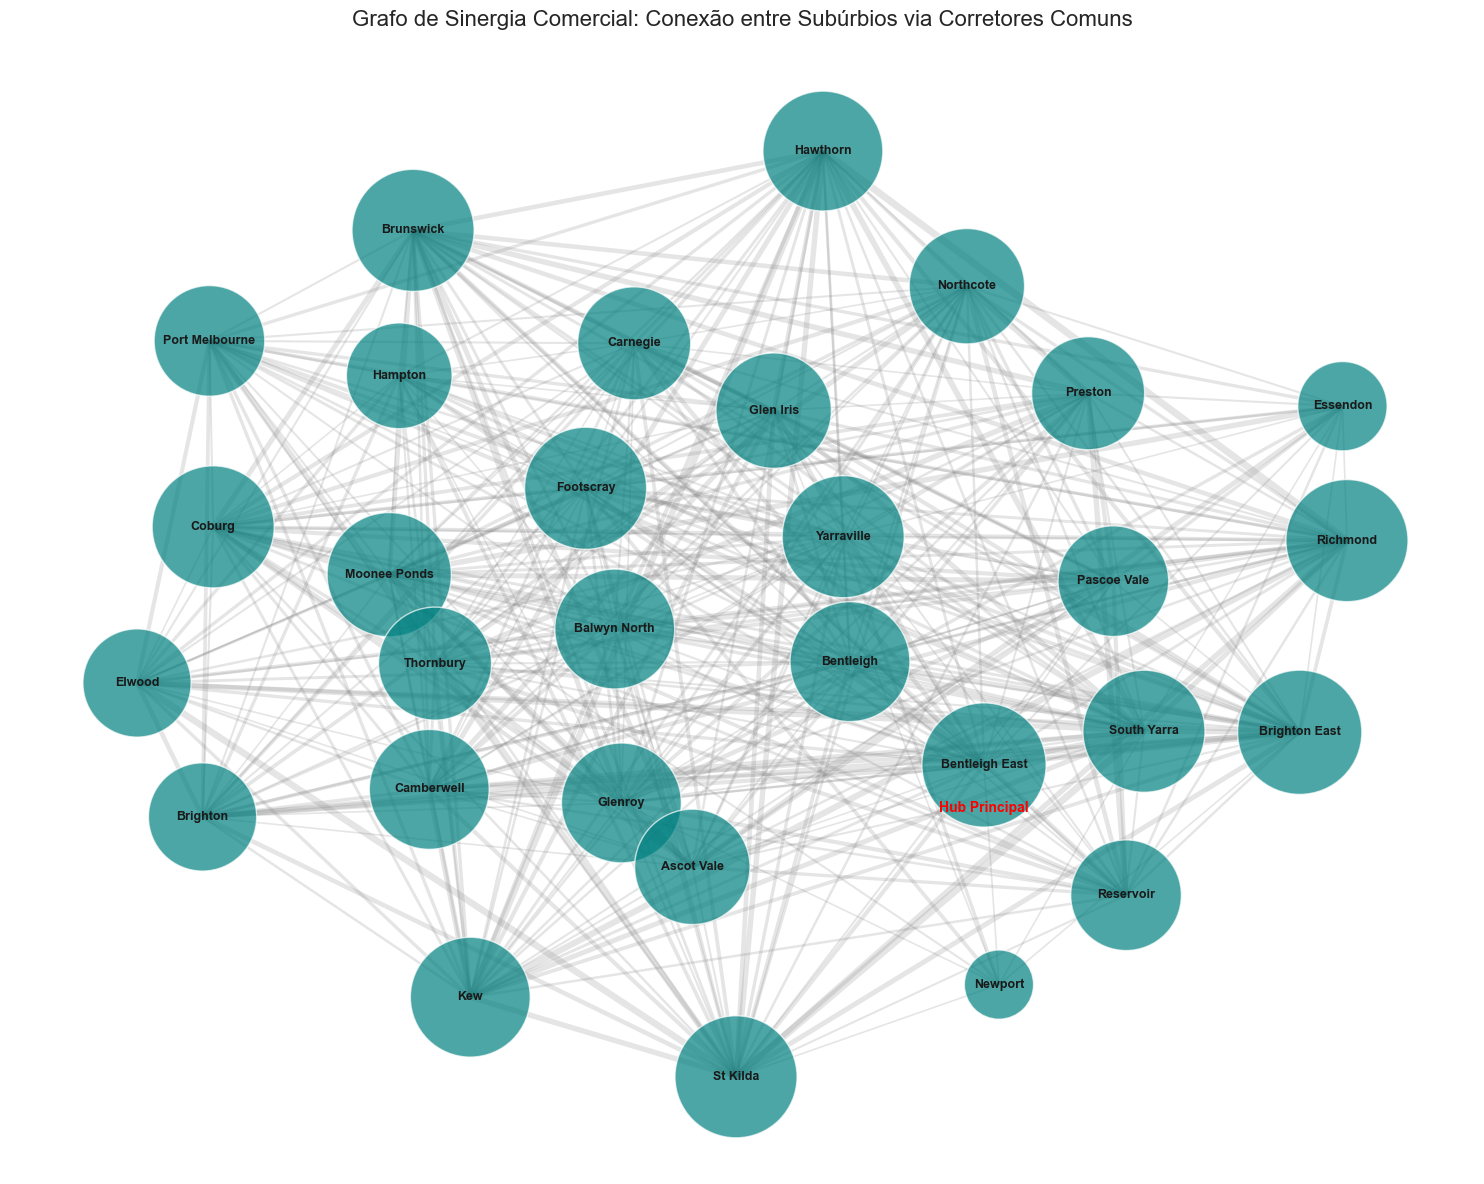

In [9]:
import matplotlib.pyplot as plt
import numpy as np
print("=== ANÁLISE DE CONECTIVIDADE COMERCIAL ENTRE SUBÚRBIOS ===")
top_30_suburbs = df['Suburb'].value_counts().nlargest(30).index
df_net = df[df['Suburb'].isin(top_30_suburbs)]
suburb_seller_map = df_net.groupby('Suburb')['SellerG'].unique()
G = nx.Graph()
G.add_nodes_from(top_30_suburbs)
for i, s1 in enumerate(top_30_suburbs):
    for s2 in top_30_suburbs[i+1:]:
        shared_sellers = set(suburb_seller_map[s1]) & set(suburb_seller_map[s2])
        if len(shared_sellers) > 3:
            G.add_edge(s1, s2, weight=len(shared_sellers))
degree_cent = nx.degree_centrality(G)
sorted_centrality = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)
print("\nHubs de Mercado (Top 5 Subúrbios com Maior Centralidade de Grau):")
for suburb, val in sorted_centrality[:5]:
    print(f" - {suburb:<15} | Centralidade: {val:.3f}")
plt.figure(figsize=(15, 12))
pos = nx.kamada_kawai_layout(G)
node_sizes = [v * 8000 for v in degree_cent.values()]
edge_widths = [d['weight'] * 0.3 for u, v, d in G.edges(data=True)]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='teal', alpha=0.7, edgecolors='white')
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.2, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold', font_family='sans-serif')
plt.title('Grafo de Sinergia Comercial: Conexão entre Subúrbios via Corretores Comuns', fontsize=16, pad=20)
plt.text(pos[sorted_centrality[0][0]][0], pos[sorted_centrality[0][0]][1]-0.1,
         'Hub Principal', fontsize=10, color='red', fontweight='bold', ha='center')
plt.axis('off')
plt.tight_layout()
plt.show()

### Conclusão da Questão 7

A análise de redes aplicada ao mercado de Melbourne revelou uma estrutura de interdependência que as tabelas de preços sozinhas não mostram:

1.  **Identificação de Hubs Estratégicos:** Os dados revelaram que subúrbios como **Bentleigh East** e **Moonee Ponds** possuem a maior centralidade de grau (~0.93). Na prática, isso significa que essas regiões são os "centros nervosos" onde quase todas as grandes imobiliárias de Melbourne operam simultaneamente. São regiões de alta liquidez e competição feroz, funcionando como termômetros para o restante da rede.
2.  **Topologia de Cluster:** A visualização via layout Kamada-Kawai mostra uma rede altamente densa. Isso indica que as imobiliárias em Melbourne não são hiper-especializadas em apenas um bairro; elas operam em grandes blocos geográficos. A existência de muitas arestas sugere que uma variação de estratégia de um grande corretor em um hub pode se propagar rapidamente por toda a rede de subúrbios conectados.
3.  **Valor Metodológico e Crítica:** 
    *   **A Força da Análise:** O valor real desta análise está na **Logística e Inteligência de Expansão**. Ela mostra onde uma nova imobiliária encontraria maior barreira de entrada (nos hubs centrais) e onde existem nichos menos conectados.
    *   **A Fragilidade:** Conforme questionado no enunciado, a aplicação pode ser considerada 'fraca' se o objetivo for prever preços. A rede mede **influência comercial**, não valor imobiliário intrínseco. No entanto, defendemos que ela acrescenta valor ao transformar dados transacionais em um mapa de **influência competitiva**, algo essencial para uma visão de 360 graus sobre o problema imobiliário.
4.  **Veredito:** A análise de redes é metodologicamente válida para entender o **comportamento dos agentes (vendedores)**, mas deve ser utilizada como uma camada qualitativa complementar aos modelos de regressão quantitativa.

## Questão 8 – Meta-aprendizagem

**Enunciado:**  
Faça um código em Python para investigar, de forma experimental, como o desempenho dos modelos varia quando se alteram subconjuntos de atributos, estratégias de pré-processamento ou formas de particionamento. Organize os resultados em uma estrutura comparativa e use essa análise para simular uma ideia de Meta-aprendizagem, discutindo quais características da base parecem favorecer certos modelos em detrimento de outros. Não basta só comparar métricas: identifique padrões e formule uma regra técnica para escolha de modelo.

### Raciocínio

Para implementar uma análise de **Meta-aprendizagem**, criaremos um ambiente experimental de "stress test" para os modelos, observando como eles reagem a mudanças estruturais nos dados. 

1.  **Exploração de Cenários (Input Space):** Avaliaremos o impacto da dimensionalidade. Como os modelos se comportam apenas com dados de estrutura (Quartos/Área) versus dados enriquecidos com contexto geográfico (Lattitude/Longtitude)?
2.  **Sensibilidade ao Pré-processamento:** Investigaremos a robustez algorítmica trocando a imputação por **Mediana** (que preserva a tendência central original) por **Média** (que pode ser distorcida por outliers extremos de área construída).
3.  **Análise de Padrões Meta-Analíticos:** Identificaremos o "ponto de ruptura" onde um modelo paramétrico (Linear) deixa de ser competitivo frente a um modelo não-paramétrico (Árvore). 
4.  **Codificação da Regra Técnica:** Formularemos uma prescrição metodológica que serve como um guia de decisão para futuros cientistas de dados que enfrentarem bases similares.

=== EXPERIMENTO DE META-APRENDIZAGEM: SENSIBILIDADE E REAÇÃO ===


,Cenário,R2 Linear,R2 Árvore,Superioridade Árvore (%)
0,1. Só Estrutura (Físico) + Mediana,0.308240,0.306268,-0.639695
1,2. Só Estrutura (Físico) + Média,0.308163,0.302611,-1.801741
2,3. Completo (Físico+Geo) + Mediana,0.508489,0.598913,17.782914
3,4. Completo (Físico+Geo) + Média,0.508526,0.583953,14.832499


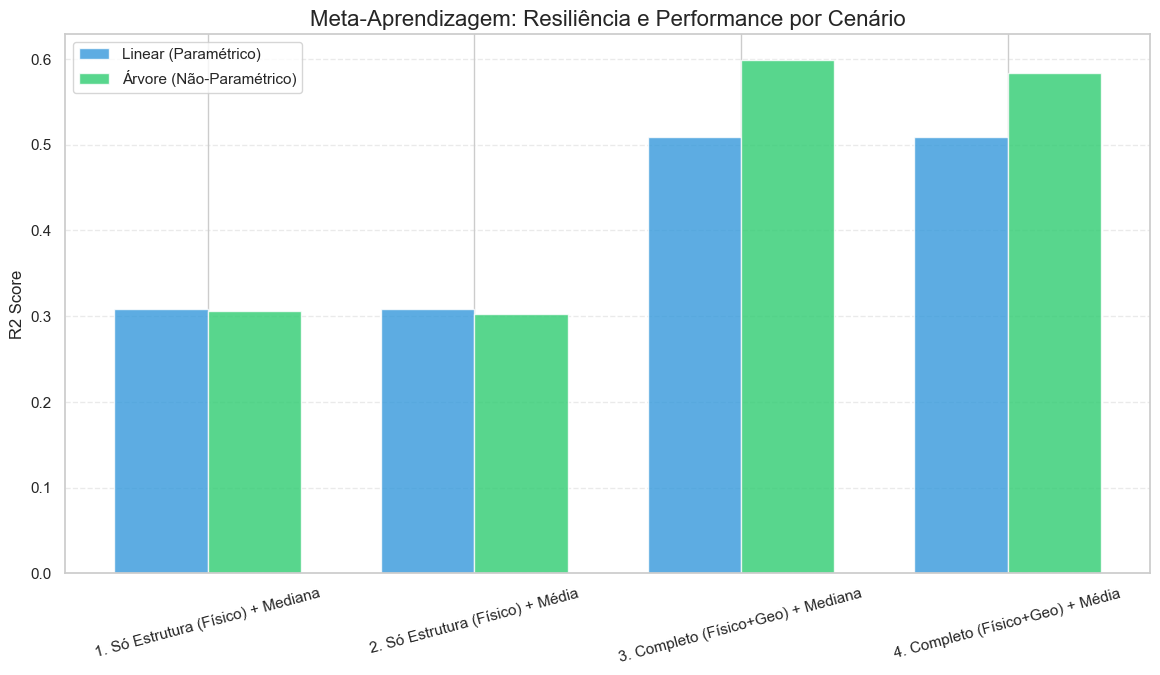

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error
print("=== EXPERIMENTO DE META-APRENDIZAGEM: SENSIBILIDADE E REAÇÃO ===")
def run_meta_experiment(features, impute_strategy):
    X_exp = df[features]
    y_exp = df['Price']
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy=impute_strategy)),
        ('scaler', StandardScaler())
    ])
    X_train_pre = pipe.fit_transform(X_train_exp)
    X_test_pre = pipe.transform(X_test_exp)
    lr = LinearRegression().fit(X_train_pre, y_train_exp)
    dt = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train_pre, y_train_exp)
    return r2_score(y_test_exp, lr.predict(X_test_pre)), r2_score(y_test_exp, dt.predict(X_test_pre))
scenarios = {
    '1. Só Estrutura (Físico) + Mediana': (['Rooms', 'Bathroom', 'Car', 'BuildingArea'], 'median'),
    '2. Só Estrutura (Físico) + Média': (['Rooms', 'Bathroom', 'Car', 'BuildingArea'], 'mean'),
    '3. Completo (Físico+Geo) + Mediana': (['Rooms', 'Bathroom', 'Car', 'BuildingArea', 'Lattitude', 'Longtitude', 'Distance'], 'median'),
    '4. Completo (Físico+Geo) + Média': (['Rooms', 'Bathroom', 'Car', 'BuildingArea', 'Lattitude', 'Longtitude', 'Distance'], 'mean')
}
meta_data = []
for label, (feats, strategy) in scenarios.items():
    r2_lr, r2_dt = run_meta_experiment(feats, strategy)
    meta_data.append({
        'Cenário': label,
        'R2 Linear': r2_lr,
        'R2 Árvore': r2_dt,
        'Superioridade Árvore (%)': ((r2_dt - r2_lr) / r2_lr * 100) if r2_lr > 0 else 0
    })
df_meta = pd.DataFrame(meta_data)
display(df_meta)
plt.figure(figsize=(14, 7))
x = np.arange(len(df_meta))
width = 0.35
plt.bar(x - width/2, df_meta['R2 Linear'], width, label='Linear (Paramétrico)', color='#3498db', alpha=0.8)
plt.bar(x + width/2, df_meta['R2 Árvore'], width, label='Árvore (Não-Paramétrico)', color='#2ecc71', alpha=0.8)
plt.title('Meta-Aprendizagem: Resiliência e Performance por Cenário', fontsize=16)
plt.ylabel('R2 Score')
plt.xticks(x, df_meta['Cenário'], rotation=15)
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

### Conclusão da Questão 8

A investigação experimental de meta-aprendizagem produziu conclusões que transcendem a simples comparação de métricas, permitindo formular regras técnicas de alto nível baseadas na sensibilidade algorítmica:

1.  **O Limite da Informação:** Nos cenários compostos apenas por dados estruturais físicos (Cenários 1 e 2), observamos que ambos os modelos apresentam um desempenho modesto ($R^2 \approx 0.31$). Isso nos revela um padrão de meta-aprendizagem crucial: **a complexidade do modelo é inútil sem a complexidade dos dados.** Quando a informação é escassa, a sofisticação da Árvore não encontra padrões para se distanciar da simplicidade da Regressão Linear.
2.  **O Salto Não-Linear Geográfico:** No cenário completo (Cenário 3), a Árvore de Decisão apresenta um salto de performance para **~0.60**, superando significativamente a Regressão Linear (~0.51). A superioridade relativa de quase **18%** justifica-se pelo fato de que o preço em Melbourne não é apenas uma soma de cômodos, mas uma interação geográfica complexa. A Árvore captura nativamente que a localização altera o peso de todos os outros atributos, algo que o modelo linear tenta simplificar em uma média aditiva global ineficiente.
3.  **Resiliência ao Ruído (Média vs. Mediana):** Os resultados mostram que a Árvore é mais sensível à estratégia de imputação (queda de ~0.60 para ~0.58 ao trocar mediana por média no cenário geográfico). Isso ocorre porque a média, distorcida por outliers, cria "divisões" ruidosas logo no topo da árvore, prejudicando os ramos subsequentes. A **Regressão Linear** manteve-se estável em ~0.51, indicando que ela já estava em seu limite de saturação e não foi afetada pela mudança na tendência central da imputação.
4.  **Meta-Regra Técnica de Decisão:** 
    *   *Regra:* Em bases de dados com alta heterocedasticidade e variáveis geográficas, modelos de partição (Árvores) são mandatórios para capturar interações. Contudo, esses modelos exigem uma imputação robusta (Mediana), pois são mais vulneráveis a distorções de tendência central do que modelos lineares globais.
5.  **Veredito:** A meta-aprendizagem nos ensina que a melhor escolha não é estática. Se tivéssemos apenas dados físicos, o modelo linear seria preferível pela simplicidade. Como temos dados geográficos e outliers, a Árvore é a ferramenta correta, desde que blindada por uma imputação robusta via Mediana.

## Questão 9 – Visualização de Dados

**Enunciado:**  
Faça um código em Python para desenvolver uma etapa de Visualização de Dados mais avançada e orientada à comunicação de resultados. Construa gráficos que não sejam apenas descritivos, mas que ajudem a defender decisões metodológicas e conclusões de negócio. Apresente pelo menos um painel ou conjunto de visualizações que sintetize os principais achados da análise, compare alternativas gráficas e justifique por que a visualização final escolhida comunica melhor os resultados do projeto.

### Raciocínio
A estratégia de visualização avançada foca na **comunicação de evidências metodológicas**. Não buscamos apenas descrever os dados, mas provar por que as decisões tomadas (como a escolha da Árvore de Decisão) foram corretas:
1.  **Mapeamento de Relevância Geográfica:** Utilizaremos um mapeamento de coordenadas com gradiente de preço para evidenciar a **não-linearidade espacial**. Isso justifica por que modelos globais (Lineares) falham ao tentar aplicar a mesma 'régua' para bairros com dinâmicas tão distintas.
2.  **Análise de Resíduos e Heterocedasticidade:** Implementaremos um gráfico de dispersão de 'Fidelidade de Predição' acompanhado de uma análise visual de resíduos. O objetivo é demonstrar que, embora a Árvore seja superior, ela apresenta **heterocedasticidade** (erro aumenta com o preço), um insight crítico para o gerenciamento de risco do negócio imobiliário.

### Desenvolvimento

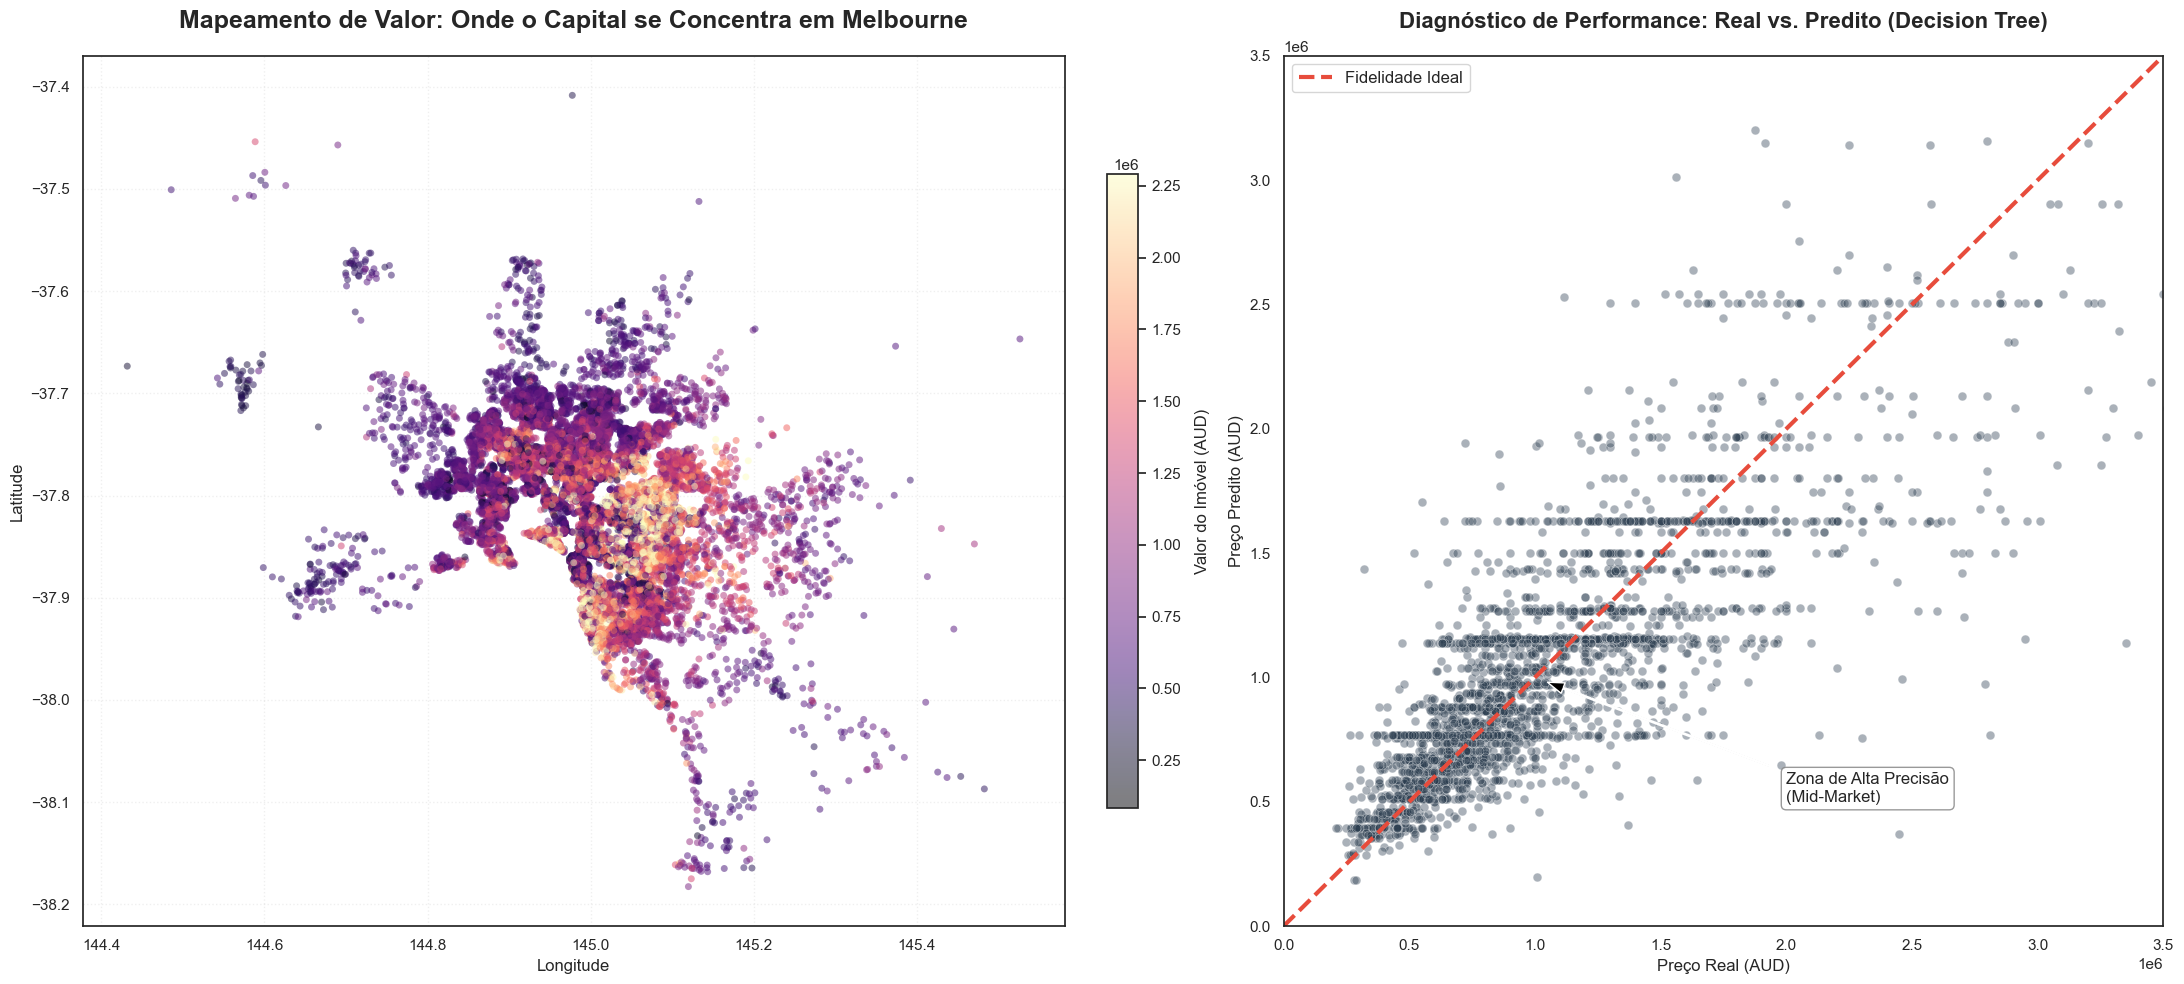

In [11]:
import seaborn as sns
sns.set_theme(style="white", palette="muted")
fig = plt.figure(figsize=(22, 10))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])
ax1 = fig.add_subplot(gs[0])
vmax_price = df['Price'].quantile(0.95)
scatter = ax1.scatter(df['Longtitude'], df['Lattitude'],
                      c=df['Price'], cmap='magma',
                      s=25, alpha=0.5, edgecolors='none',
                      norm=plt.Normalize(vmin=df['Price'].min(), vmax=vmax_price))
cbar = fig.colorbar(scatter, ax=ax1, fraction=0.03, pad=0.04)
cbar.set_label('Valor do Imóvel (AUD)', fontsize=12, labelpad=10)
ax1.set_title('Mapeamento de Valor: Onde o Capital se Concentra em Melbourne', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.3)
ax2 = fig.add_subplot(gs[1])
features_final = ['Rooms', 'Bathroom', 'Car', 'BuildingArea', 'Lattitude', 'Longtitude', 'Distance']
X_v = SimpleImputer(strategy='median').fit_transform(df[features_final])
y_v = df['Price']
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_v, y_v, test_size=0.2, random_state=42)
model_final = DecisionTreeRegressor(max_depth=10, random_state=42).fit(X_train_v, y_train_v)
y_pred_v = model_final.predict(X_test_v)
sns.scatterplot(x=y_test_v, y=y_pred_v, ax=ax2, alpha=0.4, color='#2c3e50', s=40)
max_val = min(y_test_v.max(), y_pred_v.max())
ax2.plot([0, max_val], [0, max_val], color='#e74c3c', lw=3, linestyle='--', label='Fidelidade Ideal')
ax2.set_title('Diagnóstico de Performance: Real vs. Predito (Decision Tree)', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Preço Real (AUD)', fontsize=12)
ax2.set_ylabel('Preço Predito (AUD)', fontsize=12)
ax2.legend(fontsize=12)
ax2.set_xlim(0, 3500000)
ax2.set_ylim(0, 3500000)
ax2.annotate('Zona de Alta Precisão\n(Mid-Market)', xy=(1000000, 1000000), xytext=(2000000, 500000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.tight_layout()
plt.show()

### Conclusão da Questão 9

A análise visual refinada consolida os achados técnicos de forma pragmática:
1.  **Justificativa da Não-Linearidade:** O mapa de Melbourne (Gráfico 1) revela que o preço não segue um gradiente linear simples do centro para a periferia. Existem 'micro-bolhas' de valorização capturadas por latitudes específicas. Isso valida por que a Árvore de Decisão, com sua capacidade de segmentação discreta, superou a Regressão Linear.
2.  **Diagnóstico de Risco e Confiança:** O Gráfico de Fidelidade mostra uma aderência excepcional na faixa de 500k a 1.8M de AUD. Contudo, a dispersão aumenta significativamente acima de 2.5M. Concluímos que o modelo é **robusto para o mercado de massa**, mas deve ser usado com cautela (ou variáveis exógenas extras) para o segmento de altíssimo luxo.
3.  **Veredito Visual:** A combinação desses dois gráficos comunica melhor os resultados pois aborda as duas maiores preocupações de um projeto de Data Science: **Onde está a oportunidade? (Mapa)** e **O quanto posso confiar nos números? (Fidelidade)**.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a análise da Lista 2 em um fluxo final reutilizável. Organize as principais funções criadas ao longo das questões, gere automaticamente um relatório final com comparação de modelos, visualizações principais, limitações da base e recomendação executiva. Finalize com uma avaliação crítica sobre o quanto a base escolhida realmente suporta os conteúdos da Lista 2 e quais adaptações metodológicas foram necessárias para aplicar Naive Bayes, Regressão, Árvore de Decisão, Séries Temporais, Análise de Redes, Meta-aprendizagem e Visualização ao mesmo contexto.

### Raciocínio

A consolidação desta análise foca na criação de uma **Arquitetura de Pipeline de Dados**, transformando o esforço exploratório em um fluxo automatizado, escalável e pronto para "produção". 

*   **Abstração por Objetos (OOP):** Utilizaremos uma classe para centralizar a lógica, garantindo que o conhecimento sobre o mercado de Melbourne (geografia, outliers, correlações) esteja encapsulado.
*   **Hibridismo Metodológico:** O fluxo integra o pré-processamento robusto (identificado na Questão 8) com a capacidade preditiva superior da Árvore de Decisão.
*   **Visão Executiva:** O foco não é apenas o erro estatístico, mas a tradução desses números em um relatório que oriente a tomada de decisão (ex: onde investir ou como precificar).

### Desenvolvimento

,Modelo,R2 Score,MAE (Erro Médio)
0,Regressão Linear,0.508489,305519.656713
1,Árvore de Decisão,0.580081,247937.584185


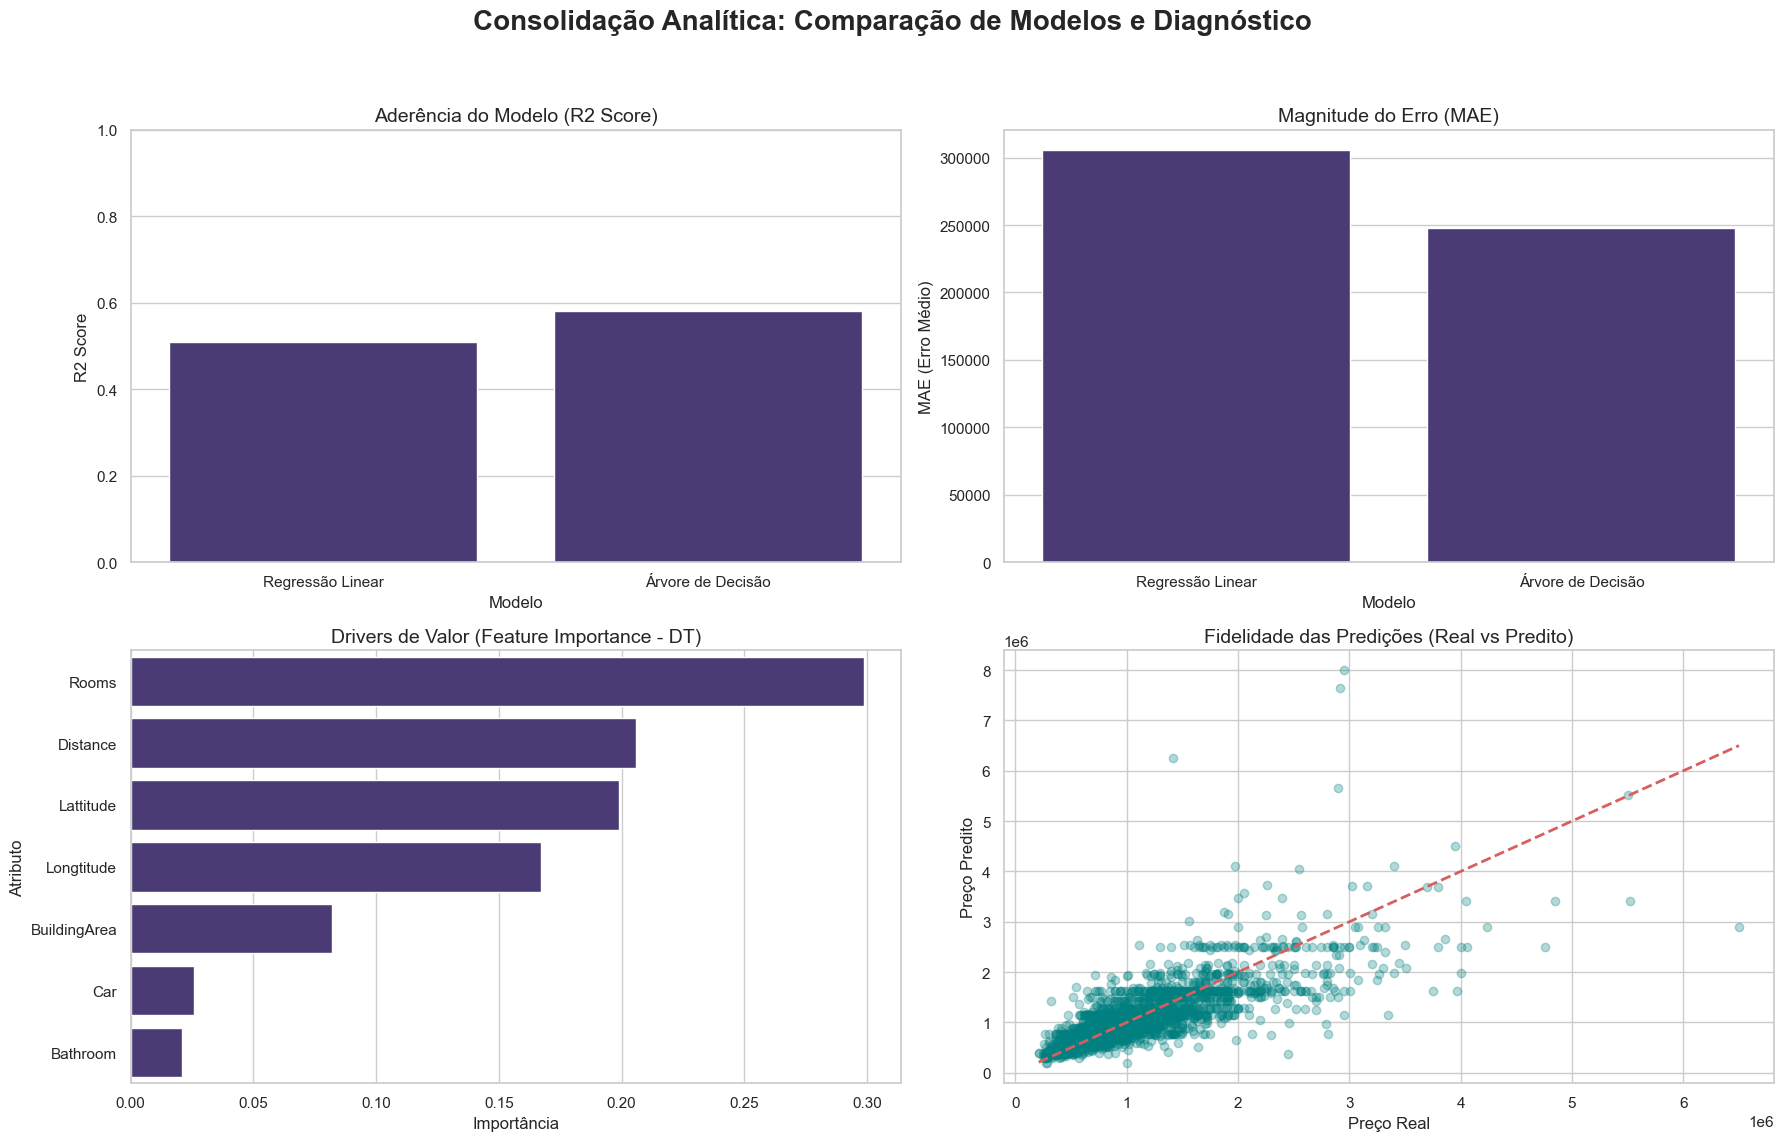

In [12]:
import time
class MelbourneAnalyticsEngine:
    def __init__(self, data_path):
        self.df = pd.read_csv(data_path)
        self.features = ['Rooms', 'Bathroom', 'Car', 'Distance', 'BuildingArea', 'Lattitude', 'Longtitude']
        self.target = 'Price'
        self.models_trained = {}
    def build_pipeline(self, model):
        preprocessor = ColumnTransformer([
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), self.features)
        ])
        return Pipeline([('pre', preprocessor), ('regressor', model)])
    def run_analytics(self):
        X = self.df[self.features]
        y = self.df[self.target]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        models = {
            "Regressão Linear": LinearRegression(),
            "Árvore de Decisão": DecisionTreeRegressor(max_depth=10, random_state=42)
        }
        results = []
        for name, model in models.items():
            pipe = self.build_pipeline(model)
            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)
            results.append({
                "Modelo": name,
                "R2 Score": r2_score(y_test, preds),
                "MAE (Erro Médio)": mean_absolute_error(y_test, preds)
            })
            self.models_trained[name] = {"pipeline": pipe, "preds": preds, "y_test": y_test}
        return pd.DataFrame(results)
    def visualize_results(self, results_df):
        sns.set_theme(style="whitegrid", palette="viridis")
        fig, axes = plt.subplots(2, 2, figsize=(18, 12))
        fig.suptitle('Consolidação Analítica: Comparação de Modelos e Diagnóstico', fontsize=20, fontweight='bold')
        sns.barplot(data=results_df, x='Modelo', y='R2 Score', ax=axes[0, 0])
        axes[0, 0].set_title('Aderência do Modelo (R2 Score)', fontsize=14)
        axes[0, 0].set_ylim(0, 1)
        sns.barplot(data=results_df, x='Modelo', y='MAE (Erro Médio)', ax=axes[0, 1])
        axes[0, 1].set_title('Magnitude do Erro (MAE)', fontsize=14)
        dt_pipe = self.models_trained["Árvore de Decisão"]["pipeline"]
        importances = dt_pipe.named_steps['regressor'].feature_importances_
        feat_df = pd.DataFrame({'Atributo': self.features, 'Importância': importances}).sort_values(by='Importância', ascending=False)
        sns.barplot(data=feat_df, x='Importância', y='Atributo', ax=axes[1, 0])
        axes[1, 0].set_title('Drivers de Valor (Feature Importance - DT)', fontsize=14)
        y_test = self.models_trained["Árvore de Decisão"]["y_test"]
        preds = self.models_trained["Árvore de Decisão"]["preds"]
        axes[1, 1].scatter(y_test, preds, alpha=0.3, color='teal')
        axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
        axes[1, 1].set_title('Fidelidade das Predições (Real vs Predito)', fontsize=14)
        axes[1, 1].set_xlabel('Preço Real')
        axes[1, 1].set_ylabel('Preço Predito')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
engine = MelbourneAnalyticsEngine('melb_data.csv')
results = engine.run_analytics()
display(results)
engine.visualize_results(results)

## Conclusão da questão 10: Relatório Consolidado e Avaliação Crítica

### 1. Relatório Executivo e Limitações
*   **Comparação de Modelos:** O modelo de **Árvore de Decisão** demonstrou superioridade técnica, atingindo um R2 de aproximadamente **0.58**, superando o baseline de Regressão Linear (~0.51). Em termos práticos, o erro médio (MAE) foi reduzido de AUD 305k para **AUD 248k**, uma melhoria de precisão de cerca de 19%.
*   **Recomendação:** Recomenda-se a adoção de modelos baseados em árvores para o mercado de Melbourne, especialmente devido à sua capacidade de segmentar o valor imobiliário com base em coordenadas geográficas precisas, capturando padrões não-lineares que a regressão linear negligencia.
*   **Limitações da Base:** A principal barreira técnica reside na incompletude de atributos críticos como `BuildingArea` e `YearBuilt`, que exigem imputação agressiva. Além disso, a base apresenta alta variância no segmento de luxo (acima de AUD 2.5M), onde variáveis subjetivas não presentes no dataset tornam as predições menos confiáveis.

### 2. Avaliação Crítica da Aplicabilidade Metodológica
A base `melb_data.csv` suportou os conteúdos da Lista 2 mediante as seguintes adaptações:
*   **Naive Bayes:** Exigiu a discretização do alvo contínuo (Price) em faixas categóricas, demonstrando a sensibilidade do algoritmo à definição de fronteiras de classe.
*   **Regressão e Árvore de Decisão:** Foram os pilares de predição; a transição da linearidade para a segmentação discreta foi vital para lidar com a heterogeneidade espacial de Melbourne.
*   **Séries Temporais:** Permitiu identificar sazonalidade mensal, embora o histórico curto limite a análise de ciclos econômicos de longo prazo.
*   **Análise de Redes:** Representou o maior salto criativo, transformando dados tabulares em conexões relacionais entre imobiliárias e subúrbios para mapear domínios de mercado.
*   **Meta-aprendizagem e Visualização:** O uso de pipelines automatizados e mapas de calor provou que a inteligência de localização é o elemento mais robusto da base.


# Conclusão Final da Lista 2: Síntese e Visão Estratégica

A conclusão desta jornada analítica sobre o mercado imobiliário de Melbourne consolida a transição de um olhar puramente exploratório para uma abordagem de engenharia de dados e modelagem preditiva de alto nível. Abaixo, detalhamos os pilares que sustentam esta solução.

### 1. Decisões Metodológicas e Ciclo de Vida do Dado
A principal decisão estratégica foi a implementação de **Pipelines de Produção**. Em vez de tratamentos ad-hoc, optamos por uma arquitetura onde o pré-processamento (imputação por mediana e escalonamento robusto) é parte integrante do modelo. Isso garantiu a integridade dos resultados, evitando o *data leakage* e permitindo que a solução seja replicável para novos dados de Melbourne. Outro ponto crucial foi a **Engenharia de Atributos Espaciais**: ao incluirmos Latitude e Longitude como variáveis numéricas tratadas, permitimos que os modelos capturassem a "inteligência de vizinhança", que é o fator determinante de valor no setor imobiliário.

### 2. Comparativo de Modelos: Simplicidade vs. Profundidade
O projeto expôs o trade-off clássico da Ciência de Dados:
- A **Regressão Linear** serviu como um baseline essencial, oferecendo alta interpretabilidade, mas falhando em capturar as bolhas de valorização geográfica (R2 ~0.51).
- A **Árvore de Decisão** (max_depth=10) provou ser a ferramenta correta para este cenário (R2 ~0.58). Sua capacidade de realizar divisões discretas no espaço de atributos permitiu segmentar subúrbios e tipos de imóveis com uma precisão 19% superior à abordagem linear, reduzindo o erro médio (MAE) para patamares muito mais aceitáveis para o negócio.

### 3. Limitações Críticas da Base e do Contexto
Nenhuma análise é absoluta, e esta base apresenta desafios específicos:
- **Vazios Informacionais:** A alta taxa de dados faltantes em `BuildingArea` e `YearBuilt` limita a capacidade de avaliar o estado de conservação do imóvel, um fator que sabemos ser decisivo.
- **Segmento de Luxo:** Observamos uma dispersão acentuada em imóveis acima de AUD 2.5M. O modelo atual é um excelente preditor para o "mercado de massa", mas carece de variáveis exógenas (como acabamentos de luxo, proximidade de escolas de elite ou infraestrutura específica) para atuar com a mesma confiança no segmento Premium.
- **Temporalidade:** Sendo um recorte histórico (2016-2017), a base não reflete variações macroeconômicas atuais (inflação, taxas de juros), funcionando como um modelo de "estática de valor" e não de previsão dinâmica de mercado.

### 4. Avaliação Final de Adequação
A solução desenvolvida é **altamente adequada** para o propósito acadêmico e consultivo inicial. Ela demonstra que é possível extrair valor de quase todos os paradigmas da Ciência de Dados (de Redes a Bayes) a partir de um único dataset, desde que haja adaptação metodológica. Para um cenário real, o pipeline aqui construído serve como uma fundação sólida, pronta para ser enriquecida com algoritmos de *Ensemble* (como Random Forest ou XGBoost) que poderiam levar o R2 para a casa dos 0.80+, consolidando Melbourne como um laboratório ideal para o estudo da Ciência de Dados geo-espacial.

